In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set(style="whitegrid")

df = pd.read_csv("E:\\weather_data.csv")

df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())

df.rename(columns={
    'Formatted Date': 'Date',
    'Temperature (C)': 'Temperature',
    'Precip Type': 'Rainfall'
}, inplace=True)

Columns: ['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%', 'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather']


In [3]:
# DATA EXPLORATION
print("\nShape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)


Shape: (8784, 8)

First 5 Rows:
       Date/Time  Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  \
0  1/1/2012 0:00    -1.8              -3.9         86                4   
1  1/1/2012 1:00    -1.8              -3.7         87                4   
2  1/1/2012 2:00    -1.8              -3.4         89                7   
3  1/1/2012 3:00    -1.5              -3.2         88                6   
4  1/1/2012 4:00    -1.5              -3.3         88                7   

   Visibility_km  Press_kPa               Weather  
0            8.0     101.24                   Fog  
1            8.0     101.24                   Fog  
2            4.0     101.26  Freezing Drizzle,Fog  
3            4.0     101.27  Freezing Drizzle,Fog  
4            4.8     101.23                   Fog  

Missing Values:
Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64

Dat

In [8]:
#DATA CLEANING

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df.ffill(inplace=True)

# Convert Date column
df['Date'] = pd.to_datetime(df['Date/Time'], errors='coerce')

# Drop invalid dates
df = df.dropna(subset=['Date'])

In [10]:
# FEATURE ENGINEERING

# Extract Month
df['Month'] = df['Date'].dt.month

#DATA VALIDATION
print("\nSummary Statistics:")
print(df.describe())

#DATA ANALYSIS

# Temperature Trend
temp_trend = df.groupby('Date')['Temp_C'].mean()

# Seasonal Pattern
seasonal_temp = df.groupby('Month')['Temp_C'].mean()


Summary Statistics:
            Temp_C  Dew Point Temp_C    Rel Hum_%  Wind Speed_km/h  \
count  8784.000000       8784.000000  8784.000000      8784.000000   
mean      8.798144          2.555294    67.431694        14.945469   
min     -23.300000        -28.500000    18.000000         0.000000   
25%       0.100000         -5.900000    56.000000         9.000000   
50%       9.300000          3.300000    68.000000        13.000000   
75%      18.800000         11.800000    81.000000        20.000000   
max      33.000000         24.400000   100.000000        83.000000   
std      11.687883         10.883072    16.918881         8.688696   

       Visibility_km    Press_kPa                 Date        Month  
count    8784.000000  8784.000000                 8784  8784.000000  
mean       27.664447   101.051623  2012-07-01 23:30:00     6.513661  
min         0.200000    97.520000  2012-01-01 00:00:00     1.000000  
25%        24.100000   100.560000  2012-04-01 11:45:00     4.000000 

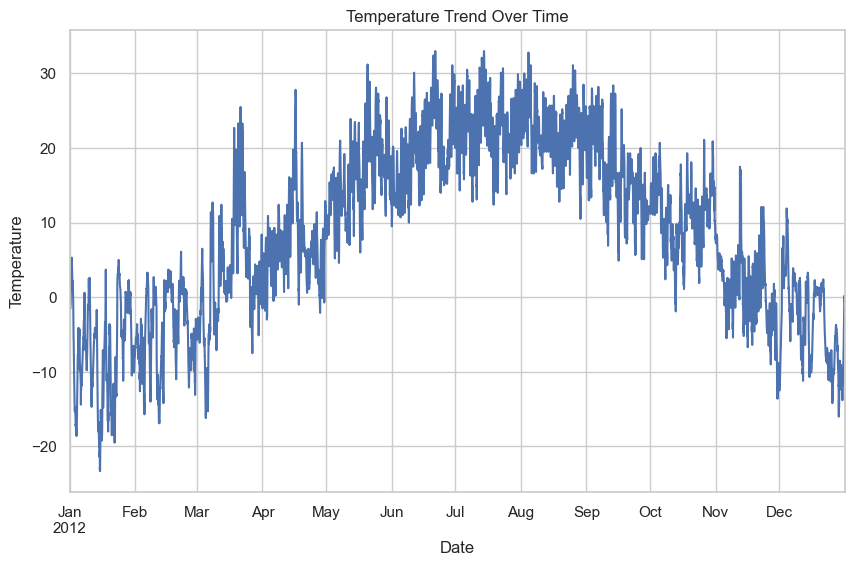

In [11]:
#Temperature Trend
plt.figure()
temp_trend.plot()
plt.title("Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

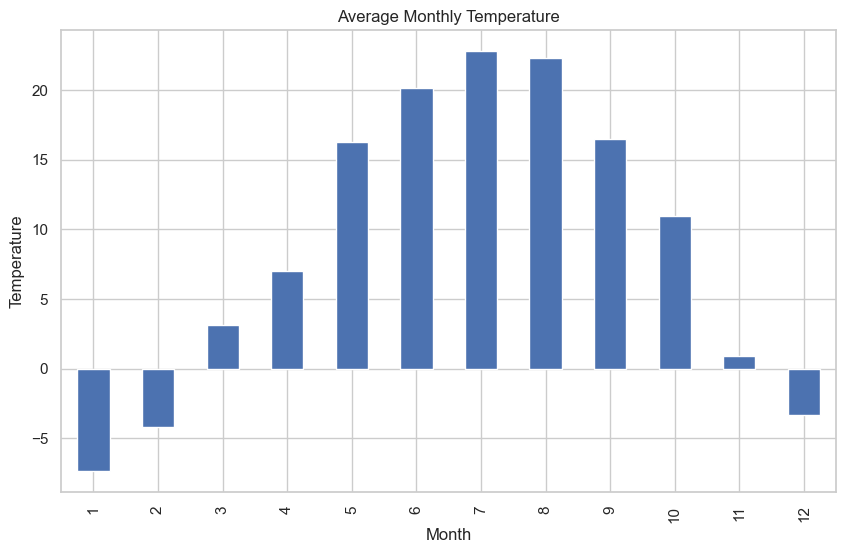

In [12]:
#Seasonal Pattern
plt.figure()
seasonal_temp.plot(kind='bar')
plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()


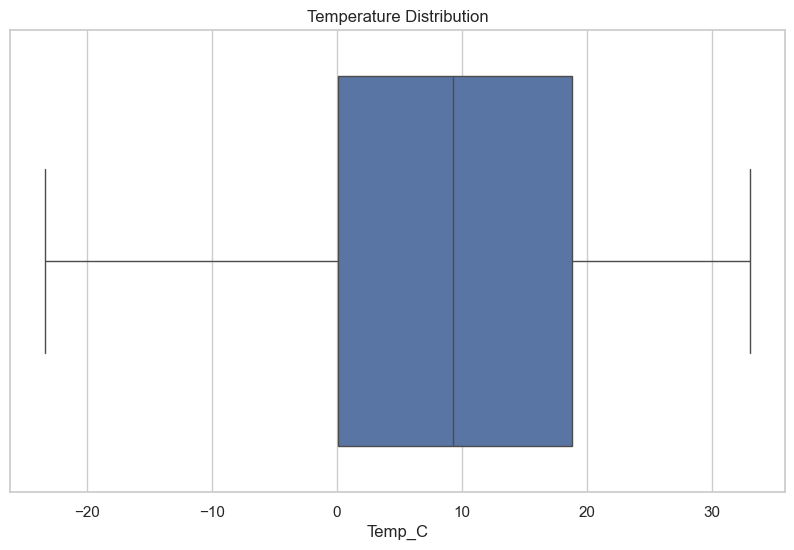

In [15]:
#Temperature Distribution
plt.figure()
sns.boxplot(x=df['Temp_C'])
plt.title("Temperature Distribution")
plt.show()

In [16]:
#STATISTICAL ANALYSIS
print("\nStatistical Analysis:")

print("Mean Temperature:", df['Temp_C'].mean())
print("Median Temperature:", df['Temp_C'].median())
print("Std Deviation:", df['Temp_C'].std())

print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))


Statistical Analysis:
Mean Temperature: 8.798144353369763
Median Temperature: 9.3
Std Deviation: 11.687882769691276

Correlation Matrix:
                    Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  \
Temp_C            1.000000          0.932714  -0.220182        -0.061876   
Dew Point Temp_C  0.932714          1.000000   0.139494        -0.095685   
Rel Hum_%        -0.220182          0.139494   1.000000        -0.092743   
Wind Speed_km/h  -0.061876         -0.095685  -0.092743         1.000000   
Visibility_km     0.273455          0.050813  -0.633683         0.004883   
Press_kPa        -0.236389         -0.320616  -0.231424        -0.356613   
Month             0.218048          0.299641   0.232040        -0.030506   

                  Visibility_km  Press_kPa     Month  
Temp_C                 0.273455  -0.236389  0.218048  
Dew Point Temp_C       0.050813  -0.320616  0.299641  
Rel Hum_%             -0.633683  -0.231424  0.232040  
Wind Speed_km/h        0.004883  